# Students Performance Analysis (EDA)


## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the student performance dataset to understand the factors affecting student scores in mathematics, reading, and writing. The insights obtained from this analysis will help in preparing the data for machine learning models.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')

: 

In [3]:
df = pd.read_csv('stud.csv')

In [4]:
df.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Dataset Overview

The dataset contains information about students including:

- Gender
- Race/Ethnicity
- Parental level of education
- Lunch type
- Test preparation course
- Math score
- Reading score
- Writing score

The dataset is used to analyze how different factors influence student academic performance.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


## Checking Missing value


In [6]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

## Checking Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
df.nunique()


gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [10]:
print("Gender Categories :", df['gender'].unique())
print("Race_ethincity Categories:", df['race_ethnicity'].unique())
print("parental_level_of_education Categories :", df['parental_level_of_education'].unique())
print("lunch Categories :", df['lunch'].unique())
print("test_preparation_course Categories :", df['test_preparation_course'].unique())


Gender Categories : ['female' 'male']
Race_ethincity Categories: ['group B' 'group C' 'group A' 'group D' 'group E']
parental_level_of_education Categories : ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
lunch Categories : ['standard' 'free/reduced']
test_preparation_course Categories : ['none' 'completed']


In [11]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df["average_score"] = df['total_score']/3

In [12]:
df.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [13]:
numerical_categories = [features for features in df.columns if df[features].dtypes != 'O']
categorical_categories = [features for features in df.columns if df[features].dtypes == 'O']

In [14]:
print(numerical_categories)
print(categorical_categories)

['math_score', 'reading_score', 'writing_score', 'total_score', 'average_score']
['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [15]:
math_full = df[df['math_score']==100]['average_score'].count()
reading_full = df[df['reading_score']==100]['average_score'].count()
writing_full= df[df['writing_score']==100]['average_score'].count()

print('Number of Students with full marks in maths is',math_full)
print('Number of Students with full marks in reading is',reading_full)
print('Number of Students with full marks in writing is',writing_full)

Number of Students with full marks in maths is 7
Number of Students with full marks in reading is 17
Number of Students with full marks in writing is 14


In [16]:
math_less = df[df['math_score']<=20]['average_score'].count()
reading_less = df[df['reading_score']<=20]['average_score'].count()
writing_less= df[df['writing_score']<=20]['average_score'].count()

print('Number of Students with less marks in maths is',math_less)
print('Number of Students with less marks in reading is',reading_less)
print('Number of Students with less marks in writing is',writing_less)

Number of Students with less marks in maths is 4
Number of Students with less marks in reading is 1
Number of Students with less marks in writing is 3


## Exploring Data (Visualization)

## Visualising average score distriubution to make some conclusion

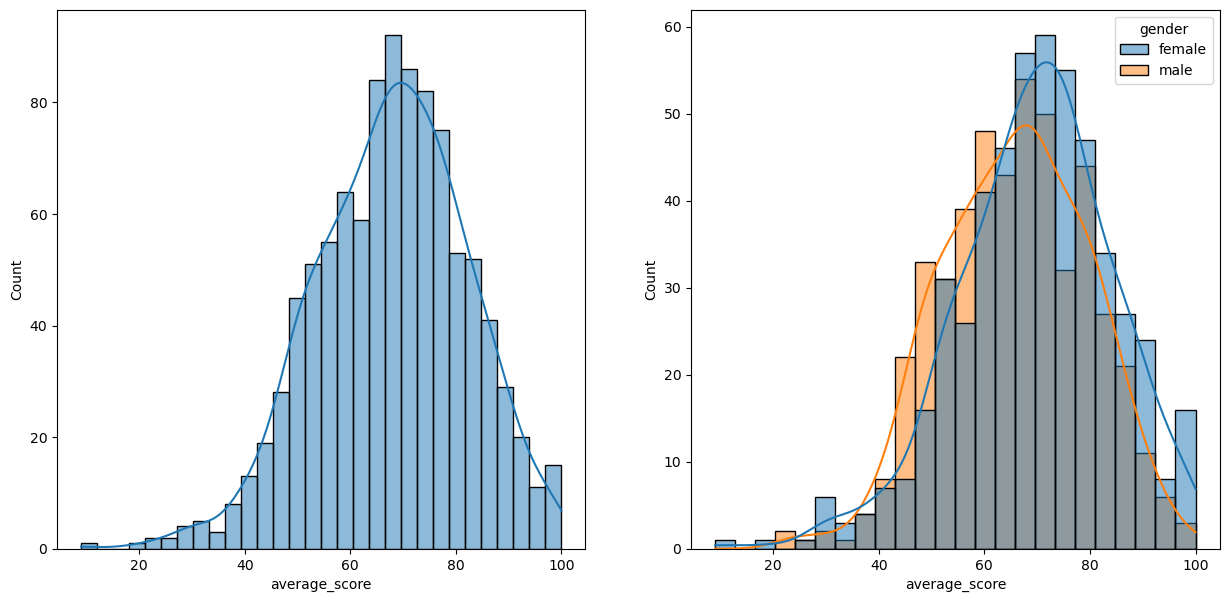

In [17]:
fig,axes = plt.subplots(1,2, figsize =(15,7))
plt.subplot(121)
sns.histplot(x= df['average_score'],bins = 30, kde = True)
plt.subplot(122)
sns.histplot(x= df['average_score'], kde = True, hue = df['gender'])
plt.show()

<Axes: xlabel='total_score', ylabel='Count'>

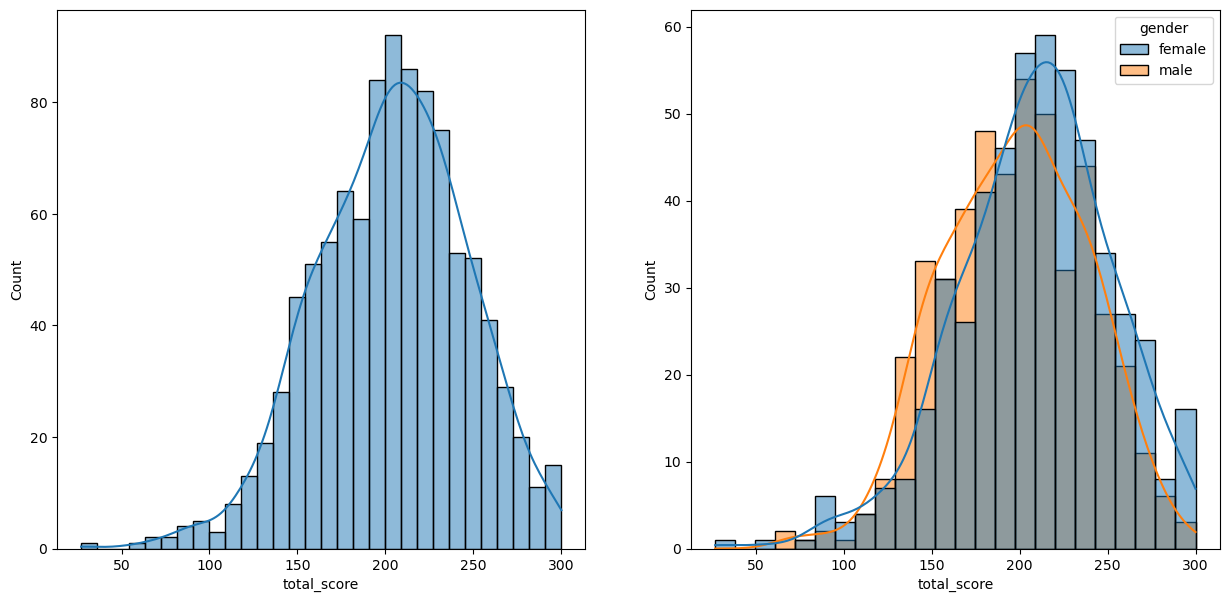

In [18]:
fig,axes = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(x=df['total_score'],bins = 30, kde = True)
plt.subplot(122)
sns.histplot(x=df['total_score'],kde = True, hue= df['gender'])

## Insights
* Female students tend to perform better overall compared to male students.

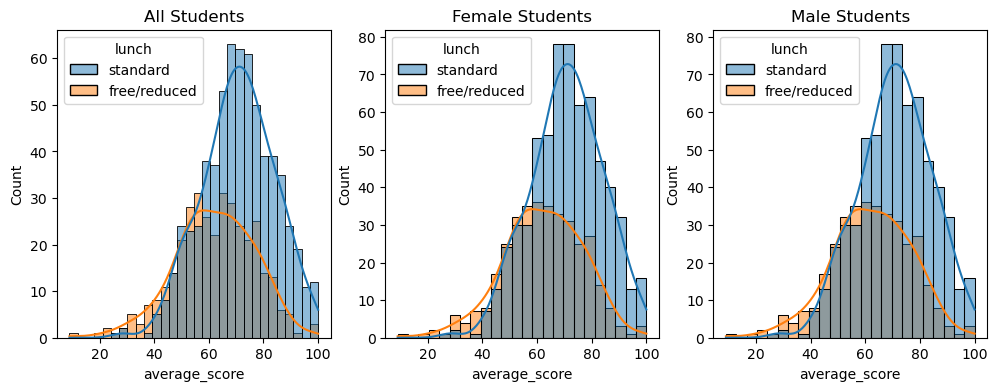

In [19]:
fig,axes = plt.subplots(1,3,figsize =(12,4))
plt.subplot(131)
sns.histplot(data =df,x =df['average_score'],bins =30,kde = True,hue = df['lunch'])
plt.title('All Students')
plt.subplot(132)
sns.histplot(data = df[df['gender']=='female'],x=df['average_score'], kde = True, hue = df['lunch'])
plt.title('Female Students')
plt.subplot(133)
sns.histplot(data =df[df['gender']=='male'],x=df['average_score'], kde = True, hue = df['lunch'])
plt.title('Male Students')
plt.show()

## Insights
* Standard lunch helps perform well in exam
* Standard lunch helps perform well in exam whether it a male or female

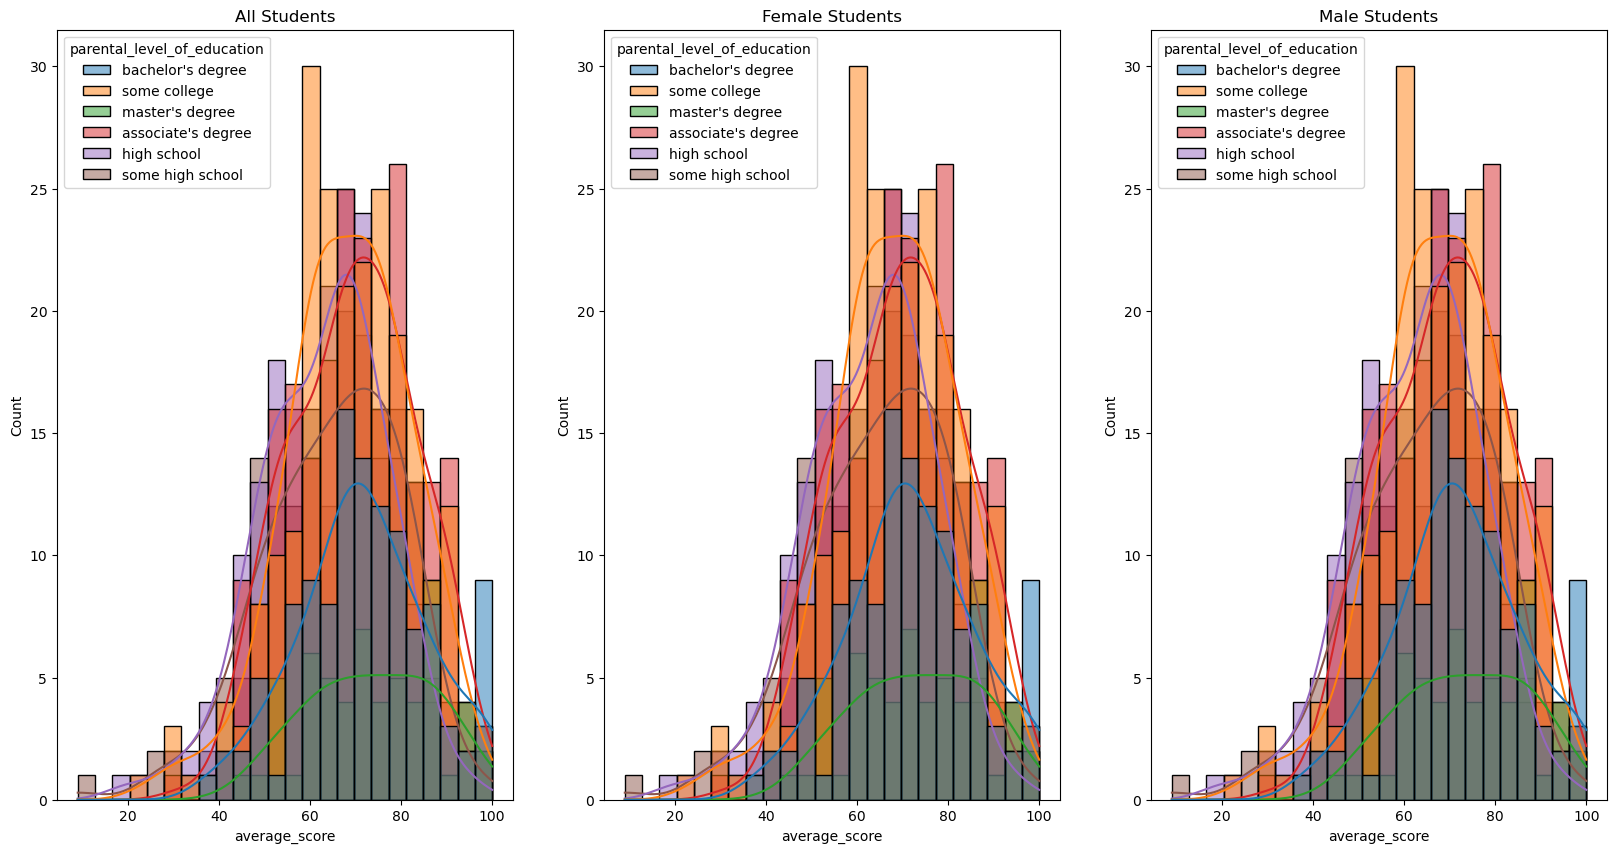

In [20]:
fig,axes = plt.subplots(1,3,figsize=(20,10))
plt.subplot(131)
sns.histplot(data=df, x = df['average_score'], kde = True, hue = df['parental_level_of_education'])
plt.title('All Students')
plt.subplot(132)
sns.histplot(data = df[df['gender']=='female'],x=df['average_score'], kde = True, hue = df['parental_level_of_education'])
plt.title('Female Students')
plt.subplot(133)
sns.histplot(data = df[df['gender']=='male'], x = df['average_score'], kde = True, hue =df['parental_level_of_education'])
plt.title('Male Students')
plt.show()

## Insights
* In general parents education don't help students to perform well in exam.
* 2nd plot we can see that there is no effect of parent's education on female students.
* 3nd plot shows that parents whos education is of associate's degree or master's degree their male child tends to perform well in exam.

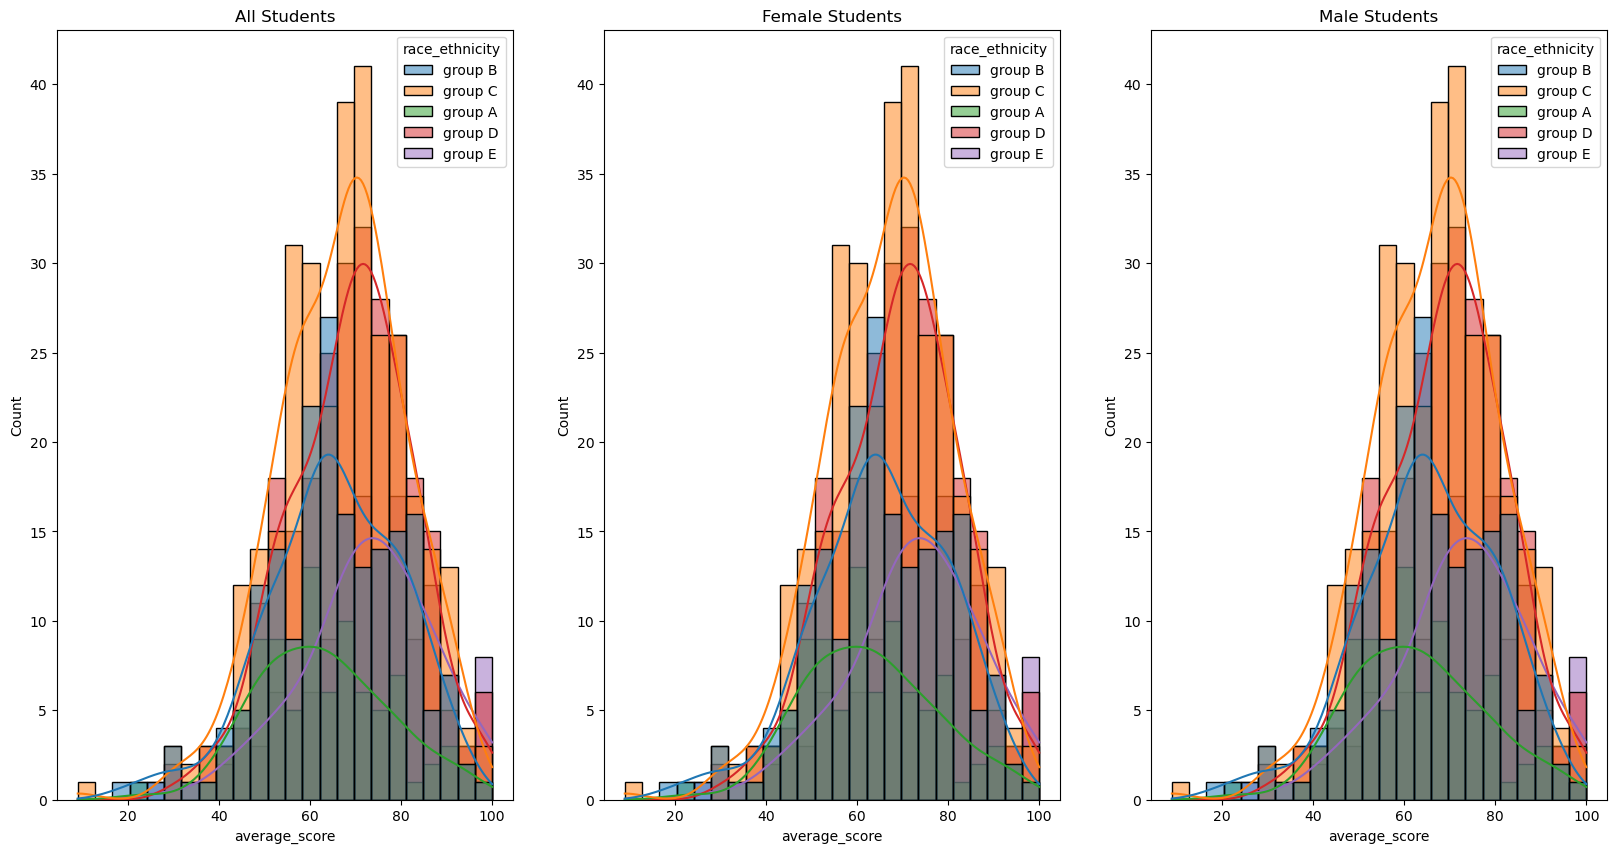

In [21]:
fig,axes = plt.subplots(1,3,figsize =(20,10))
plt.subplot(131)
sns.histplot(data = df, x = df['average_score'], kde = True, hue = df['race_ethnicity'])
plt.title('All Students')
plt.subplot(132)
sns.histplot(data = df[df['gender']=='female'] , x =df['average_score'], kde = True, hue =df["race_ethnicity"])
plt.title('Female Students')
plt.subplot(133)
sns.histplot(data = df[df['gender']=='male'], x = df['average_score'], kde = True, hue = df["race_ethnicity"])
plt.title('Male Students')
plt.show()

## Insights
* Students Group A and Group B tends to perform poorly in exam.
* Students of Group A and Group B tends to perform poorly in exam irrespective of whether they are male or female.


## Maximum score of students in all three subjects

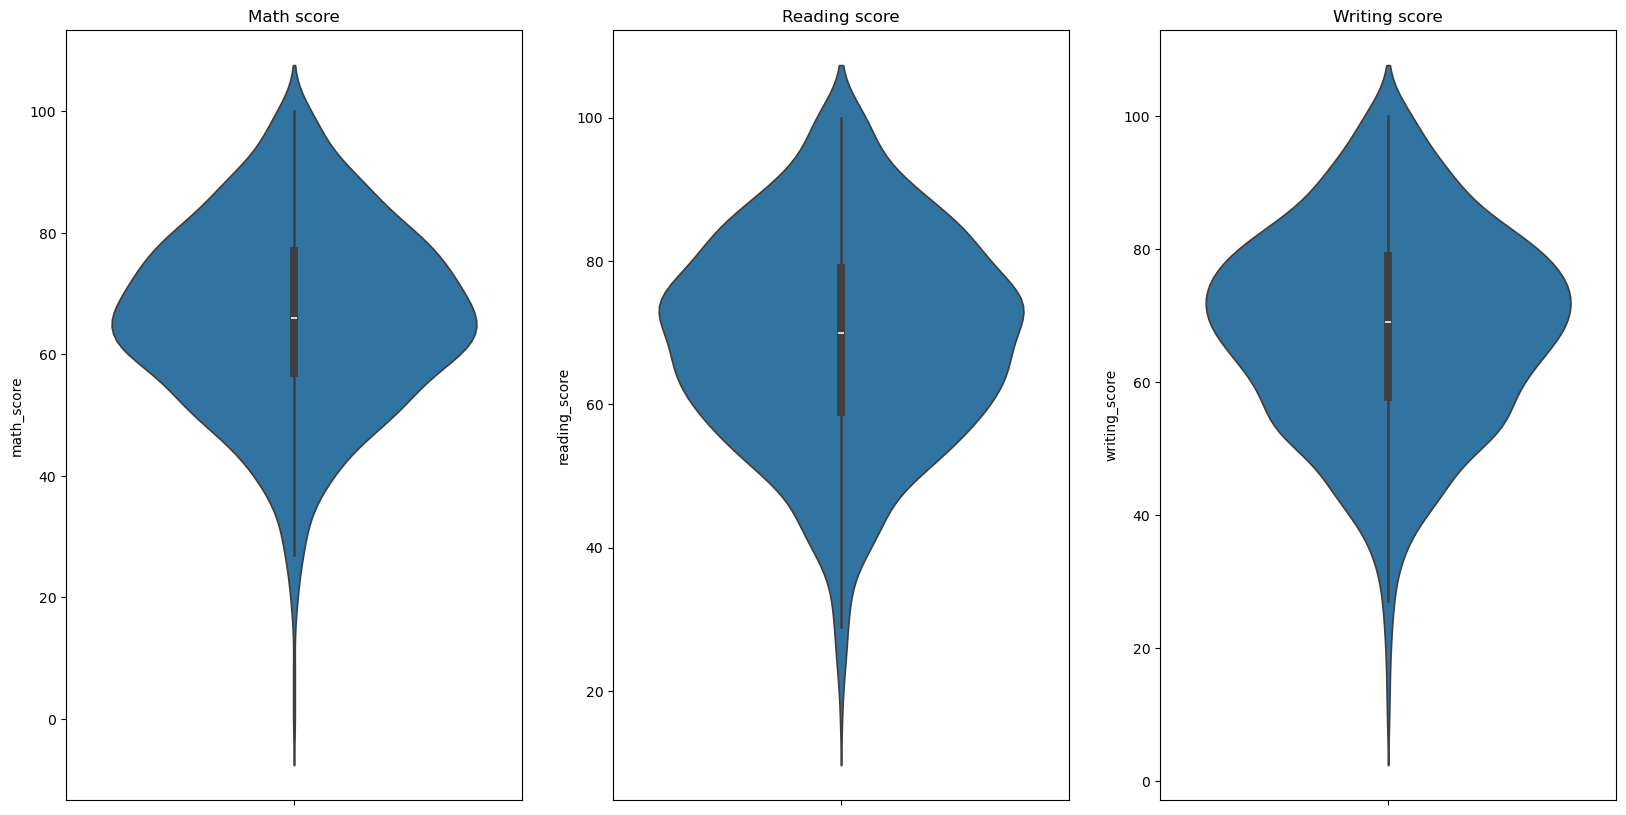

In [22]:
plt.figure(figsize = (20,10))
plt.subplot(131)
sns.violinplot(data = df, y='math_score')
plt.title('Math score')
plt.subplot(132)
sns.violinplot(data = df , y='reading_score')
plt.title("Reading score")
plt.subplot(133)
sns.violinplot(data = df, y='writing_score')
plt.title('Writing score')
plt.show()

## Insights
* From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80.

## Multivariate analysis using pieplot

(np.float64(-1.25), np.float64(1.25), np.float64(-1.25), np.float64(1.25))

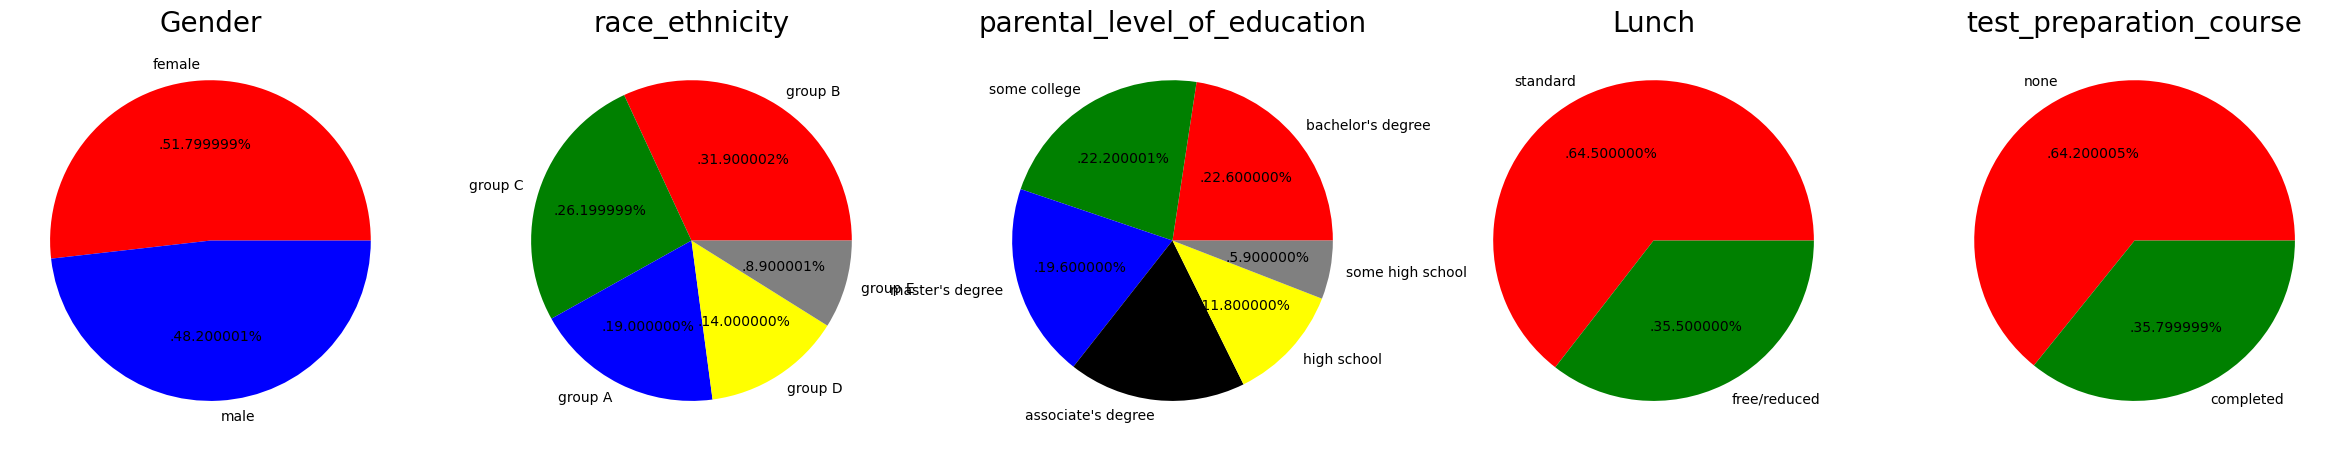

In [23]:
plt.rcParams['figure.figsize'] = (30,12)

plt.subplot(151)
size = df['gender'].value_counts()
label = 'female','male'
color ='red','blue'
plt.pie(size, labels = label,colors = color,autopct='.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')

plt.subplot(152)
size = df['race_ethnicity'].value_counts()
label ='group B', 'group C', 'group A', 'group D', 'group E'
color= 'red','green','blue','yellow','grey'
plt.pie(size, labels=label,colors=color, autopct='.%2f%%')
plt.title('race_ethnicity', fontsize = 20)
plt.axis('off')

plt.subplot(153)
size = df['parental_level_of_education'].value_counts()
label = "bachelor's degree" ,'some college', "master's degree" ,"associate's degree",'high school', 'some high school'
color = 'red','green','blue','black','yellow', 'grey'
plt.pie(size, labels =label, colors=color, autopct= '.%2f%%')
plt.title('parental_level_of_education', fontsize= 20)
plt.axis('off')

plt.subplot(154)
size = df['lunch'].value_counts()
label = 'standard', 'free/reduced'
color = 'red','green'
plt.pie(size, labels = label,colors= color, autopct= '.%2f%%')
plt.title('Lunch',fontsize = 20)
plt.axis('off')

plt.subplot(155)
size = df['test_preparation_course'].value_counts()
label ='none', 'completed'
color = 'red', 'green'
plt.pie(size, labels = label,colors= color, autopct ='.%2f%%')
plt.title('test_preparation_course',fontsize = 20)
plt.axis('off')

## Insights
* Number of male and female students is almost equal.
* Number of students is from Group C.
* Number of students whose parental education is some college is greater followed closely by assosicate's degree.
* Number of students who have Standard lunch are greater.
* Number of students who have not enrolled in any test preparation course are greater.

## Feature vise visualisation

## GENDER COLUMN
* How is distribution of Gender ?
* Is gender has any impact on student's performance ?

## Univariate Analysis(How is distribution of gender?)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20632\4234029459.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x=df['gender'], palette='bright',ax=ax[0],saturation= 0.95)


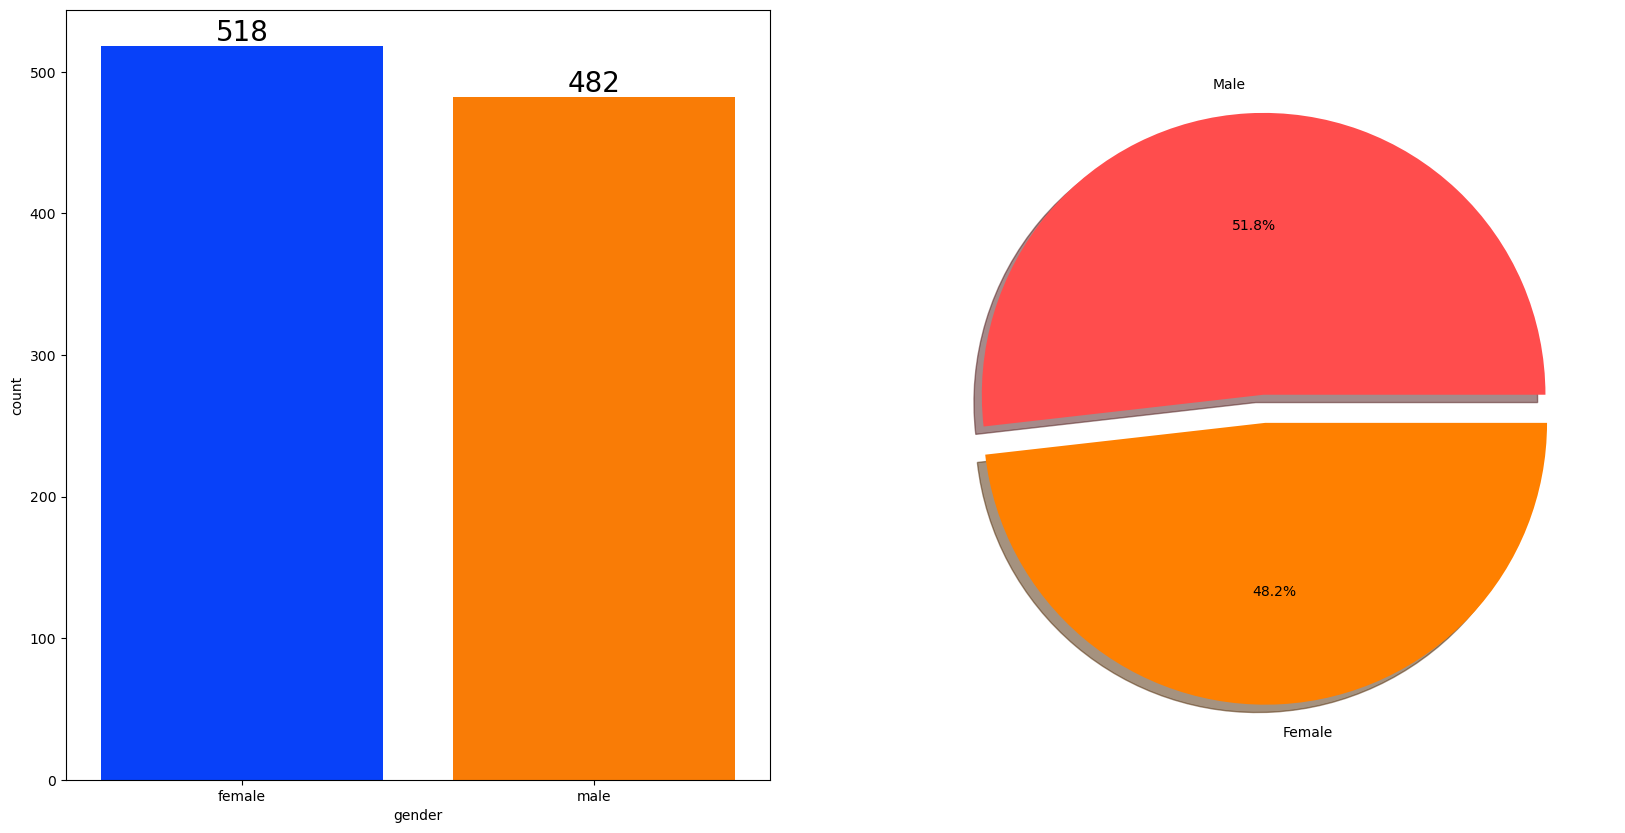

In [24]:
fig, ax=plt.subplots(1,2,figsize =(20, 10))

sns.countplot(data=df,x=df['gender'], palette='bright',ax=ax[0],saturation= 0.95)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size = 20)

plt.pie(data= df,x=df['gender'].value_counts(),labels =['Male','Female'],explode =[0,0.1],shadow= True,autopct='%1.1f%%',colors=['#ff4d4d','#ff8000'])
plt.show()

## Insights
* Gender has balanced data with female students are 518 (48%) and male students are 482 (51%).

## Bivariate Analysis(Is Gender has any impact on students performance?)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20632\504502471.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  female_scores = [gender_group['average_score'][0],gender_group['math_score'][0]]
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20632\504502471.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  male_scores = [gender_group['math_score'][1],gender_group['math_score'][1]]


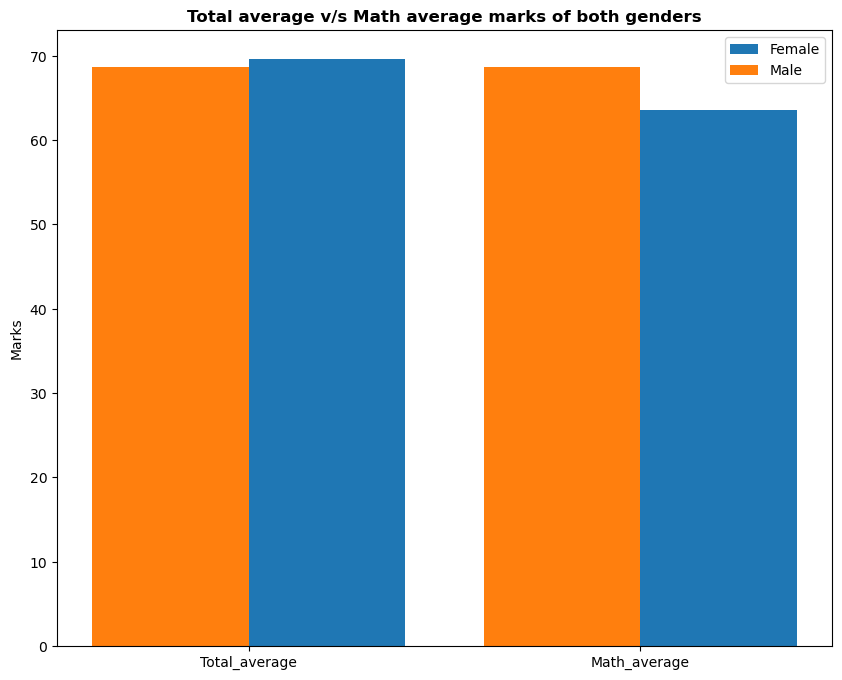

In [25]:
gender_group = df.groupby('gender').mean(numeric_only =True)
gender_group

plt.figure(figsize=(10,8))

x = ['Total_average','Math_average']

female_scores = [gender_group['average_score'][0],gender_group['math_score'][0]]
male_scores = [gender_group['math_score'][1],gender_group['math_score'][1]]

X_axis = np.arange(len(x))

plt.bar(x= X_axis + 0.2,height= female_scores,width =0.4, label = 'Female' )
plt.bar(x= X_axis - 0.2,height = male_scores,width = 0.4,label = 'Male' )

plt.xticks(X_axis,x)
plt.ylabel("Marks")
plt.title('Total average v/s Math average marks of both genders',fontweight = 'bold')
plt.legend()
plt.show()

## Insights
* On an average females have a better overall score than males.
* whereas males have scored higher in Maths.

## Race ethnicity Column
* How is Group wise distribution ?
* Is Race/Ehnicity has any impact on student's performance ?

## Univariate Analysis(How is Group wise Distribution?)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20632\4075172410.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x =df['race_ethnicity'],palette = 'bright',ax = ax[0], saturation = 0.95)


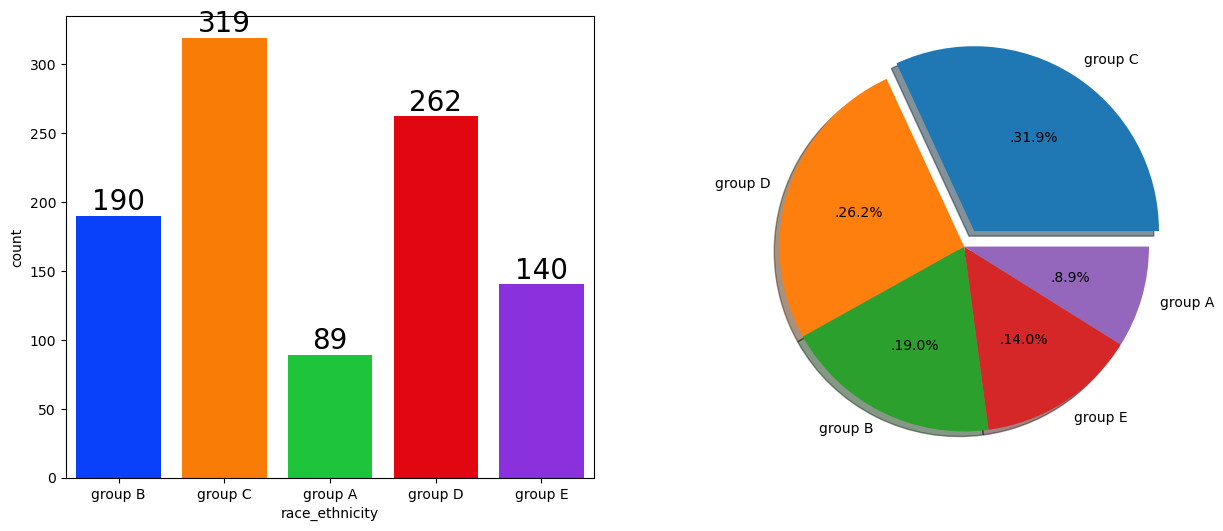

In [26]:
fig,ax = plt.subplots(1,2, figsize = (15,6))

sns.countplot(data = df, x =df['race_ethnicity'],palette = 'bright',ax = ax[0], saturation = 0.95)

for container in ax[0].containers:
    ax[0].bar_label(container, color ='black',size = 20)

plt.subplot(122)
plt.pie(x= df['race_ethnicity'].value_counts(),labels = df['race_ethnicity'].value_counts().index,shadow = True, explode = [0.1,0,0,0,0], autopct = '.%1.1f%%')
plt.show()

## Insights
* Most of the students belong to group C and group D
* Least number of students belongs to group A

## Bivariate Analysis (Is race ethnicity has any impact on students performance)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20632\1753409055.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = data.index, y = data.values, palette =palette[i],ax=ax[i])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20632\1753409055.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = data.index, y = data.values, palette =palette[i],ax=ax[i])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20632\1753409055.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = data.index, y = data.values, palette =palette[i],ax=ax[i])


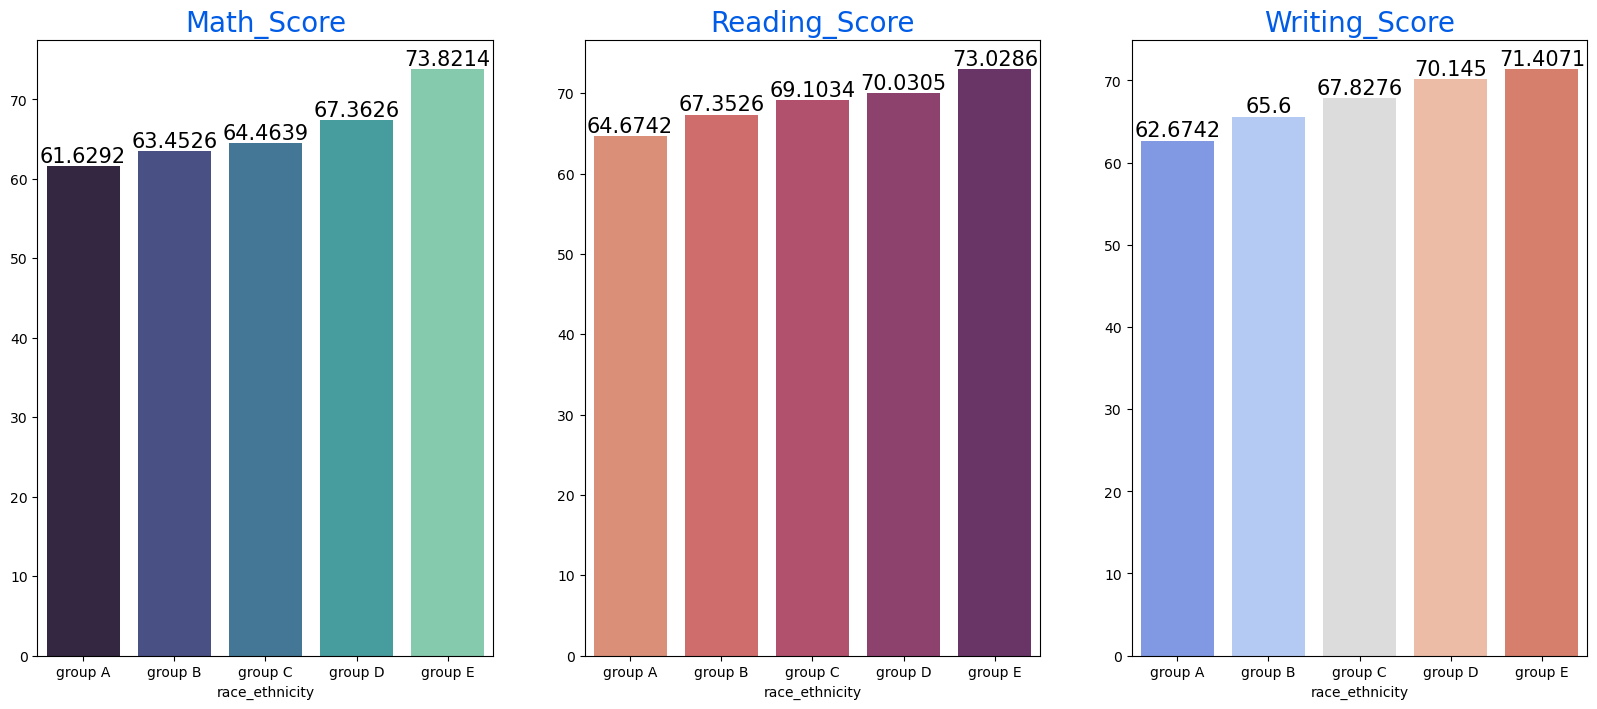

In [27]:
group_data2 = df.groupby('race_ethnicity')

subjects = ['math_score','reading_score','writing_score']
palette =['mako','flare','coolwarm']

fig, ax = plt.subplots(1,3, figsize=(20,8))
for i, sub in enumerate(subjects):
    data = group_data2[sub].mean()

    sns.barplot(x = data.index, y = data.values, palette =palette[i],ax=ax[i])

    ax[i].set_title(sub.title(), color= '#005ce6', size= 20)

    for container in ax[i].containers:
        ax[i].bar_label(container, color='black', size = 15)

            

    
    

## Insights
* Group E have scores highest marks
* Group A have scores lowest marks
* Students from a Socioeconomics status have a lower avg in all course subject.

## Parental level Education column
* What is educational background of student's parent ?
* parental education has any impact on student's performance ?

## Univariate Analysis( What is educational Background of students parents??)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20632\2665175690.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['parental_level_of_education'],palette='Blues')


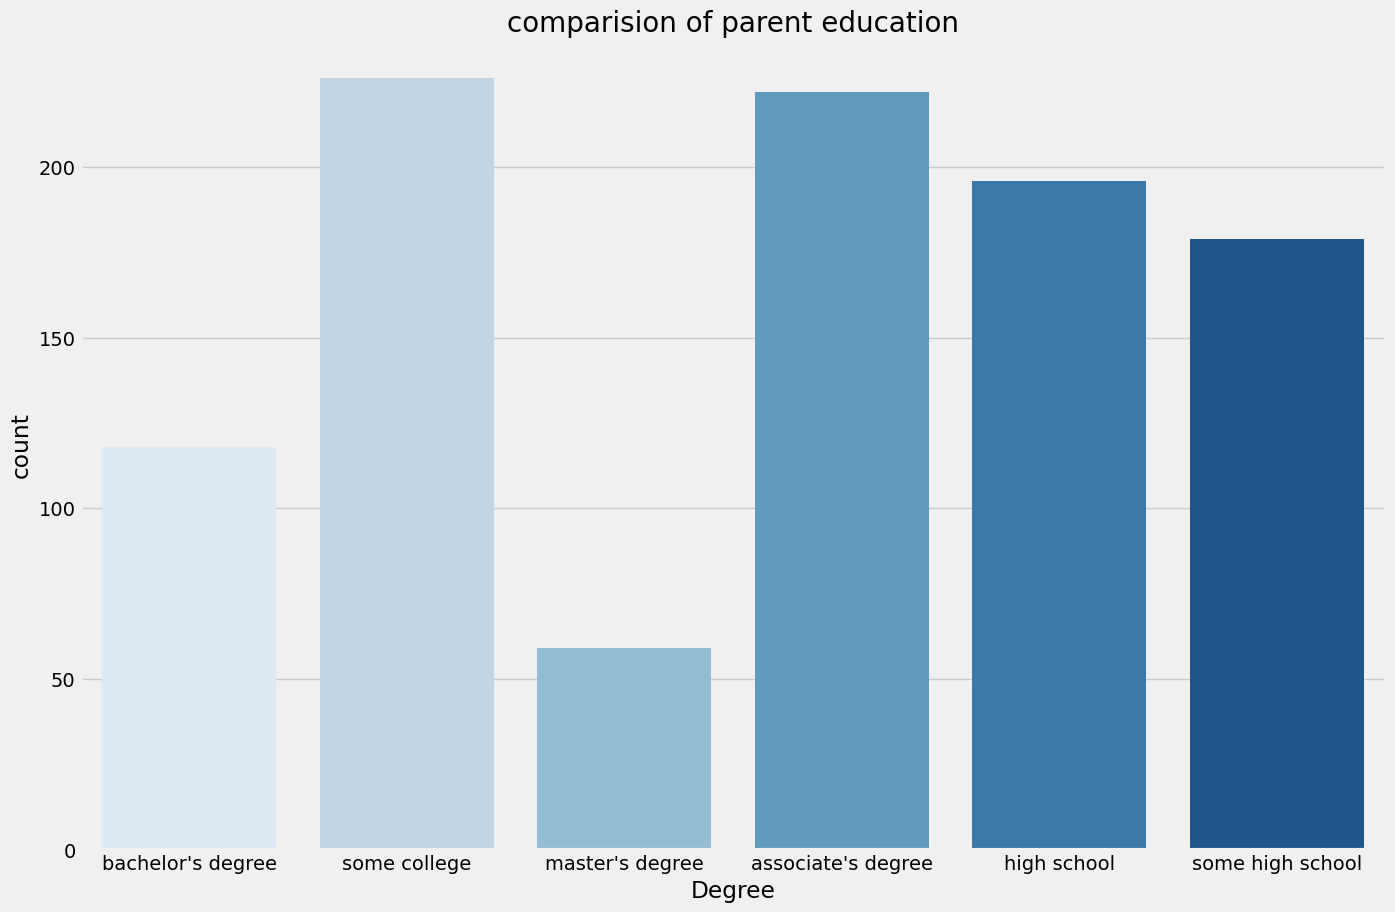

In [28]:
plt.rcParams['figure.figsize']=(15,10)
plt.style.use('fivethirtyeight')
sns.countplot(x=df['parental_level_of_education'],palette='Blues')
plt.title('comparision of parent education',fontsize= 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

## Insights
* Largest number of parents are from some college

## Bivariate Analysis (Is parental education has any impact on students performance)

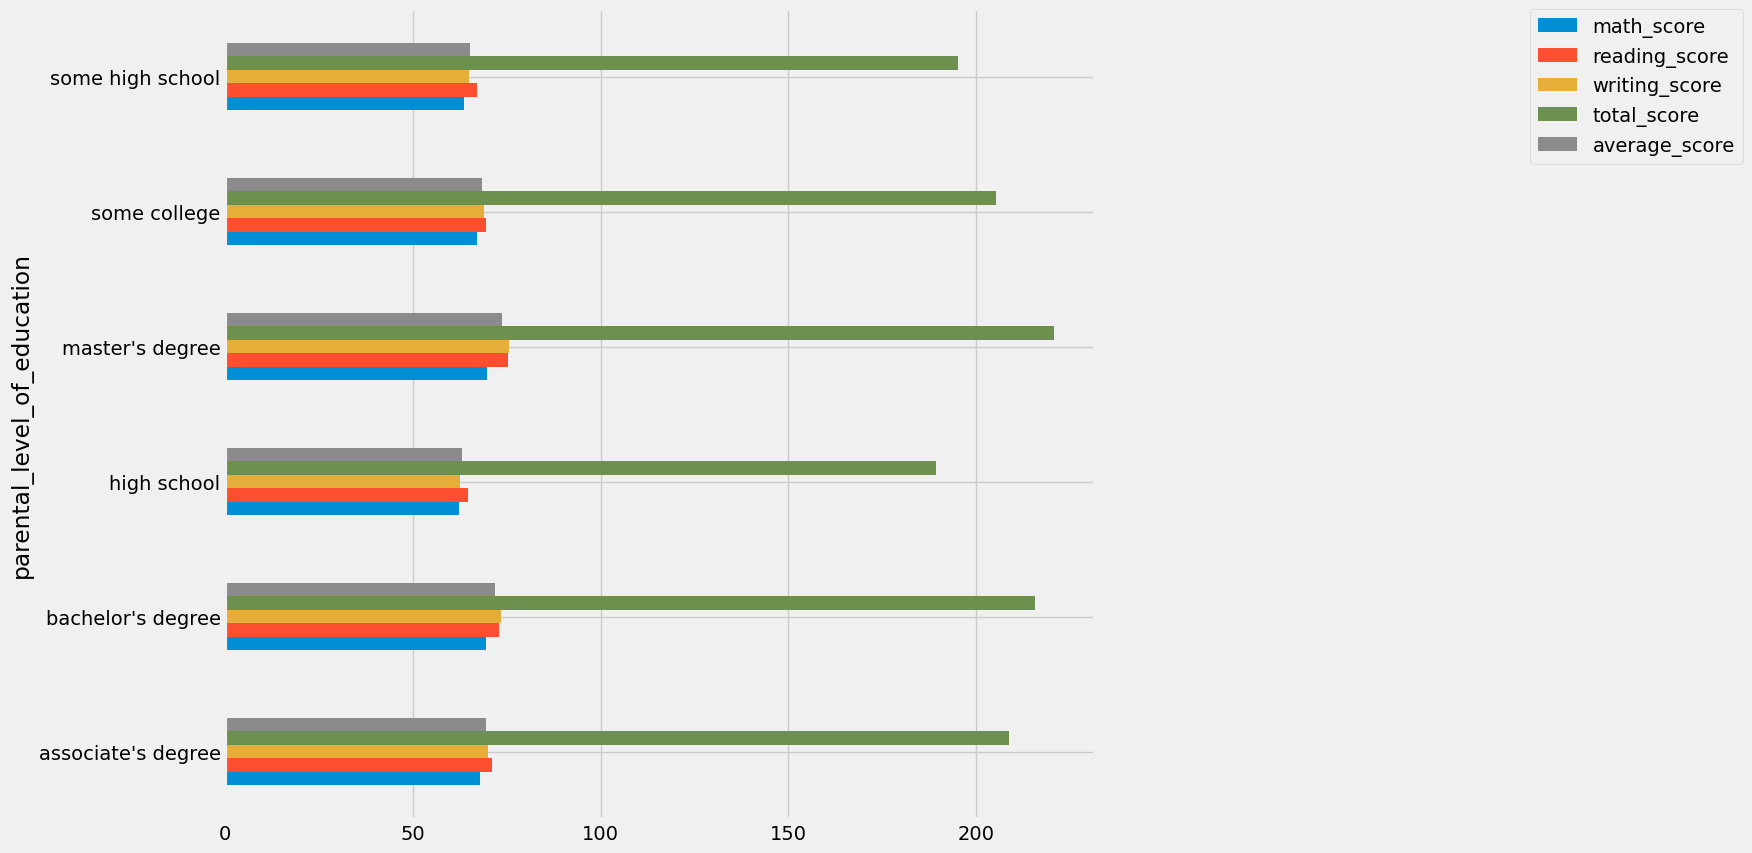

In [29]:
df.groupby('parental_level_of_education').agg('mean',numeric_only=True).plot(kind ='barh', figsize =(10,10))
plt.legend(bbox_to_anchor =(1.5,1),loc =2,borderaxespad = 0.)
plt.show()

## Insights
* The score of students who parents posses masters and bachlors degree areh higher than other

## Lunch column
* Which type of lunch is most common among students ?
* What is the effect of lunch type on test results?

## Univariate analysis( Which type of lunch is most common among students?)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20632\3061669727.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= df['lunch'],palette ='PuBu')


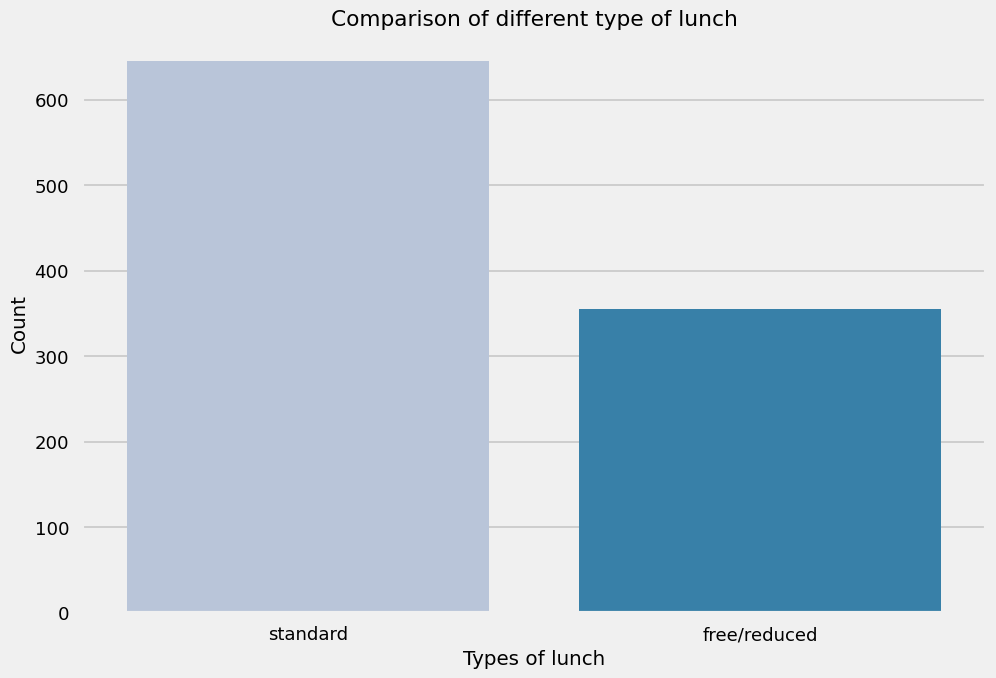

In [30]:
plt.rcParams['figure.figsize']=(15,9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(x= df['lunch'],palette ='PuBu')
plt.title('Comparison of different type of lunch')
plt.xlabel('Types of lunch')
plt.ylabel('Count')
plt.show()

## Insights
* Students being served Standard lunch was more than free lunch

## Bivariate analysis(Is lunch type intake has any impact on students performance)

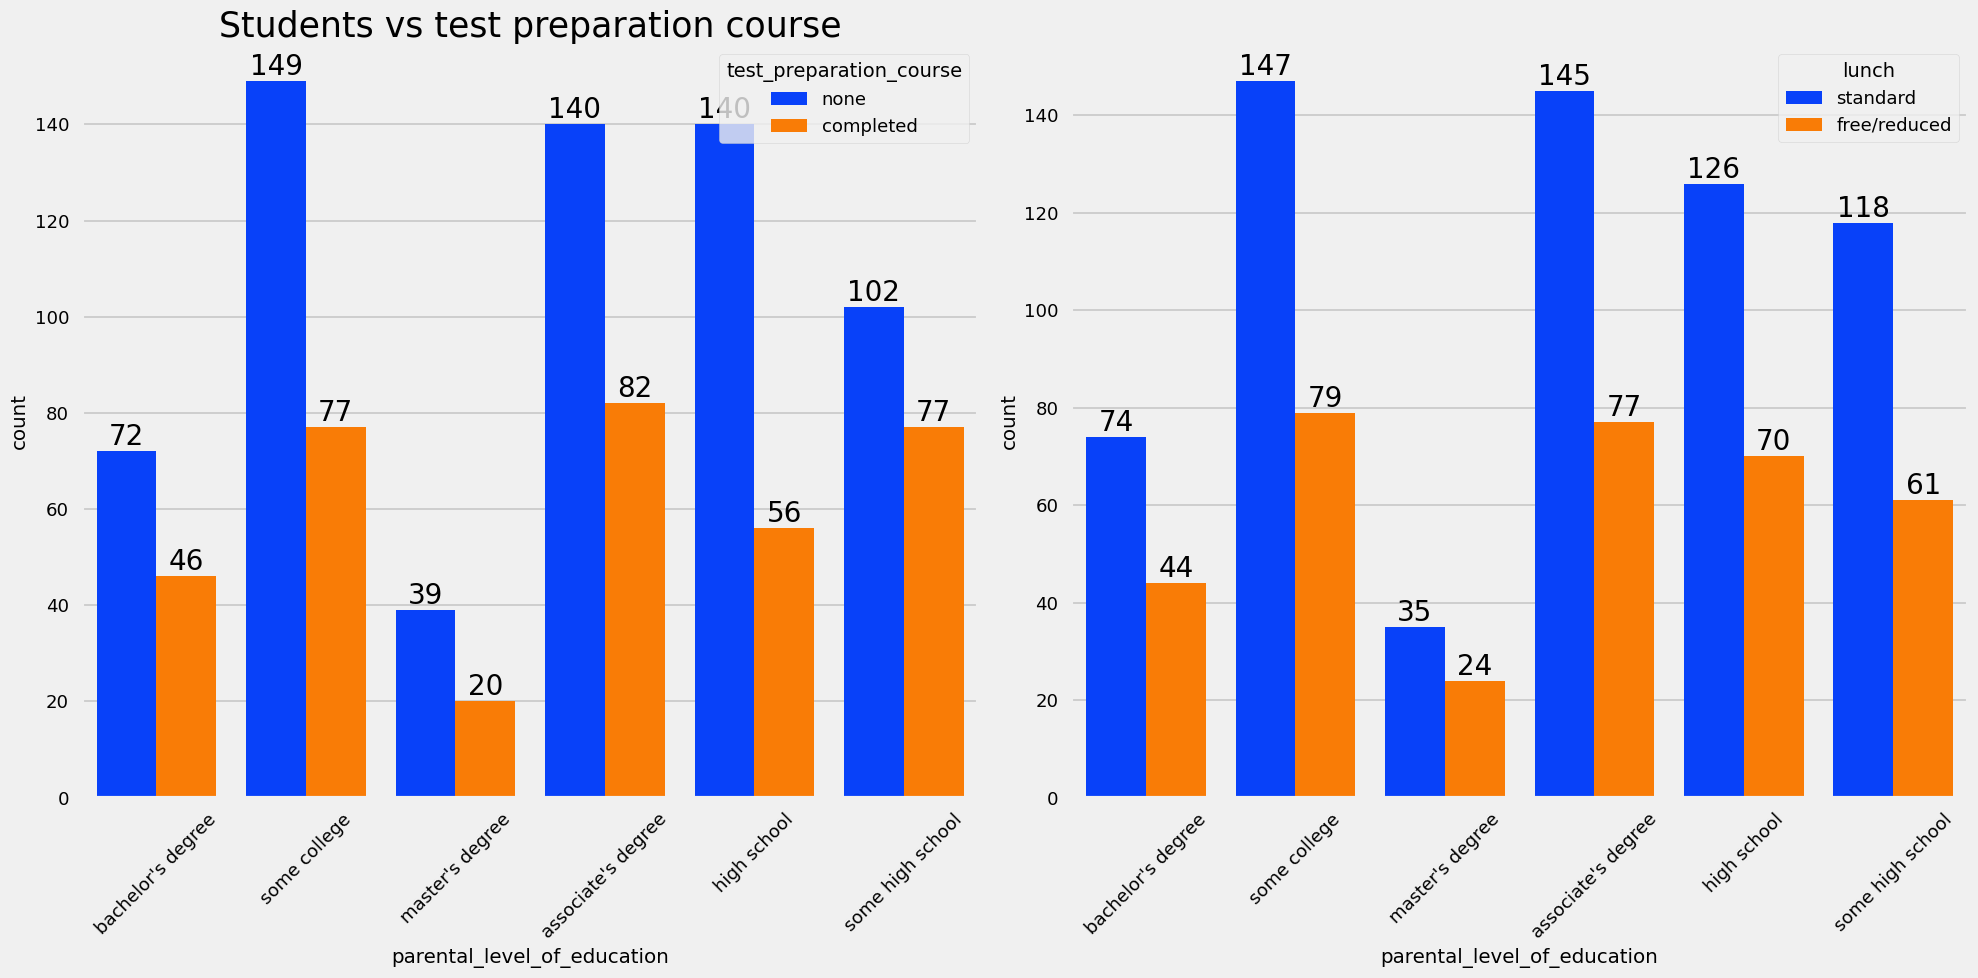

In [31]:
fig, ax = plt.subplots(1,2,figsize =(20,10))

sns.countplot(x=df['parental_level_of_education'],data =df,palette ='bright' ,hue= 'test_preparation_course', ax =ax[0],saturation= 0.95)
ax[0].set_title('Students vs test preparation course',color = 'black',size = 25)

for container in ax[0].containers:
    ax[0].bar_label(container,fontsize = 20)
plt.setp(ax[0].get_xticklabels(), rotation=45)

sns.countplot(x=df['parental_level_of_education'],data =df,palette ='bright' ,hue = 'lunch', ax= ax[1],saturation= 0.95)

for container in ax[1].containers:
    ax[1].bar_label(container,fontsize = 20)

plt.setp(ax[1].get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

## Insights
* Students who get Standard lunch tend to perform better than students who get free/reduced lunch.

## Test preparation course column
* Is Test preparation course has any impact on student's performance ?

## Bivariate Analysis( Is Test preparation course has any impact on student's performance ?)

<Axes: xlabel='lunch', ylabel='writing_score'>

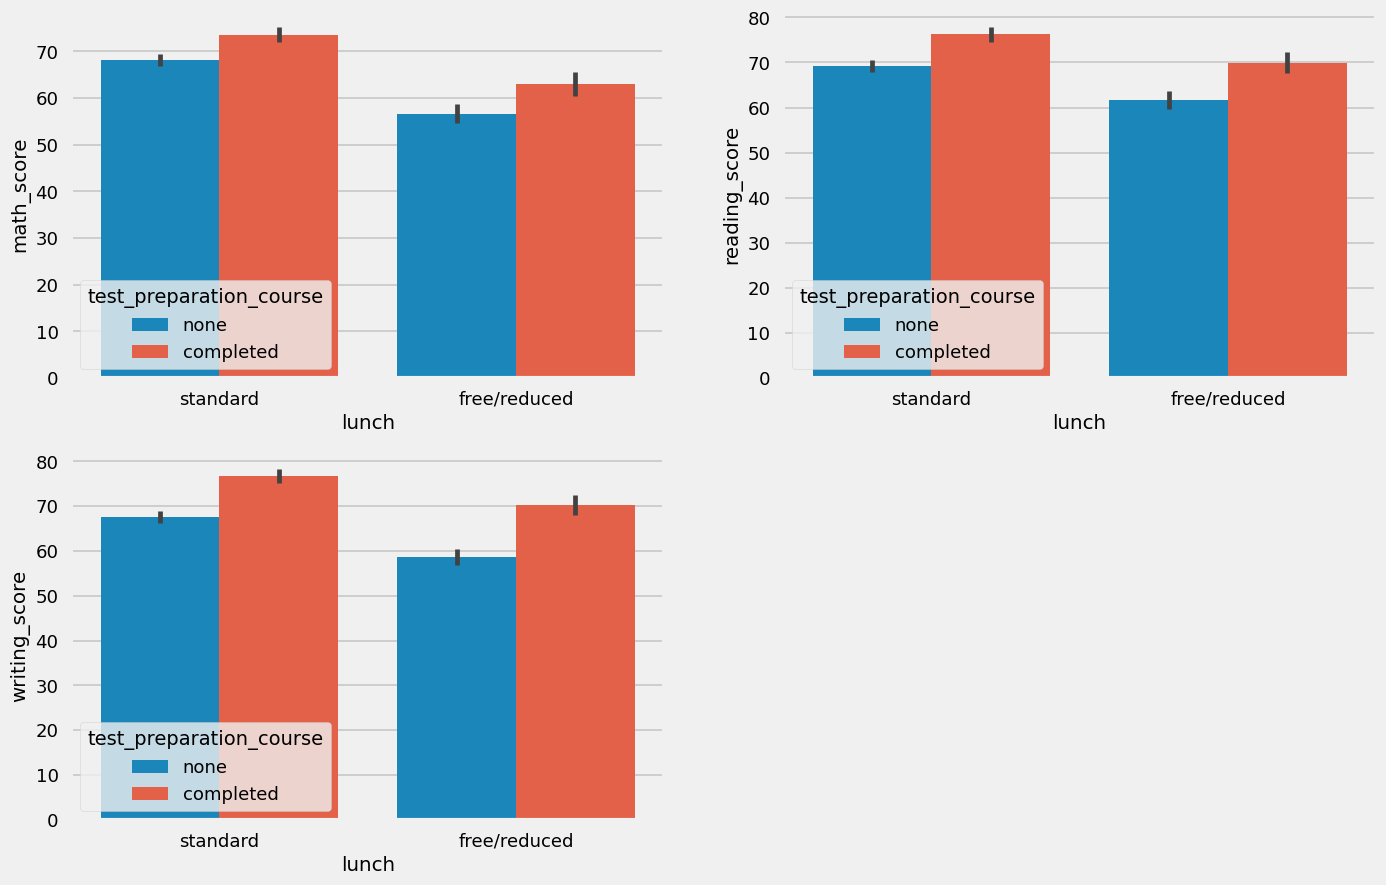

In [32]:
plt.figure(figsize=(15,10))
plt.subplot(221)
sns.barplot(x=df['lunch'],y=df['math_score'], hue = df['test_preparation_course'])
plt.subplot(222)
sns.barplot(x=df['lunch'],y=df['reading_score'], hue = df['test_preparation_course'])
plt.subplot(223)
sns.barplot(x=df['lunch'],y=df['writing_score'], hue = df['test_preparation_course'])


## Insights
* Students who have completed the test preparation course scores highest in all three subjects than who haven't taken the course.

## Checking outliers

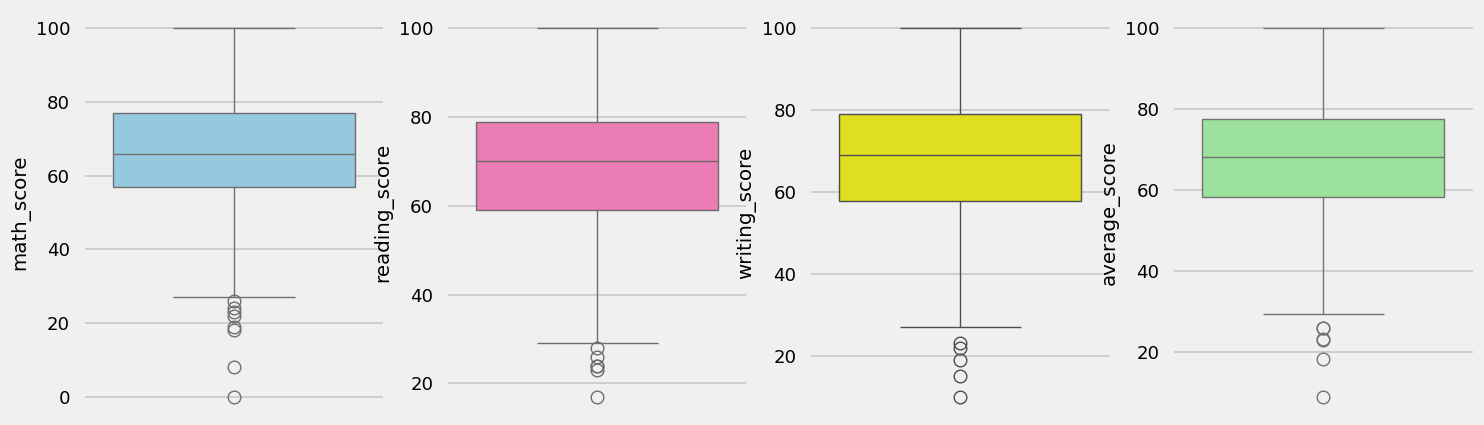

In [33]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average_score'],color='lightgreen')
plt.show()

## Multivariate analysis using pairplot

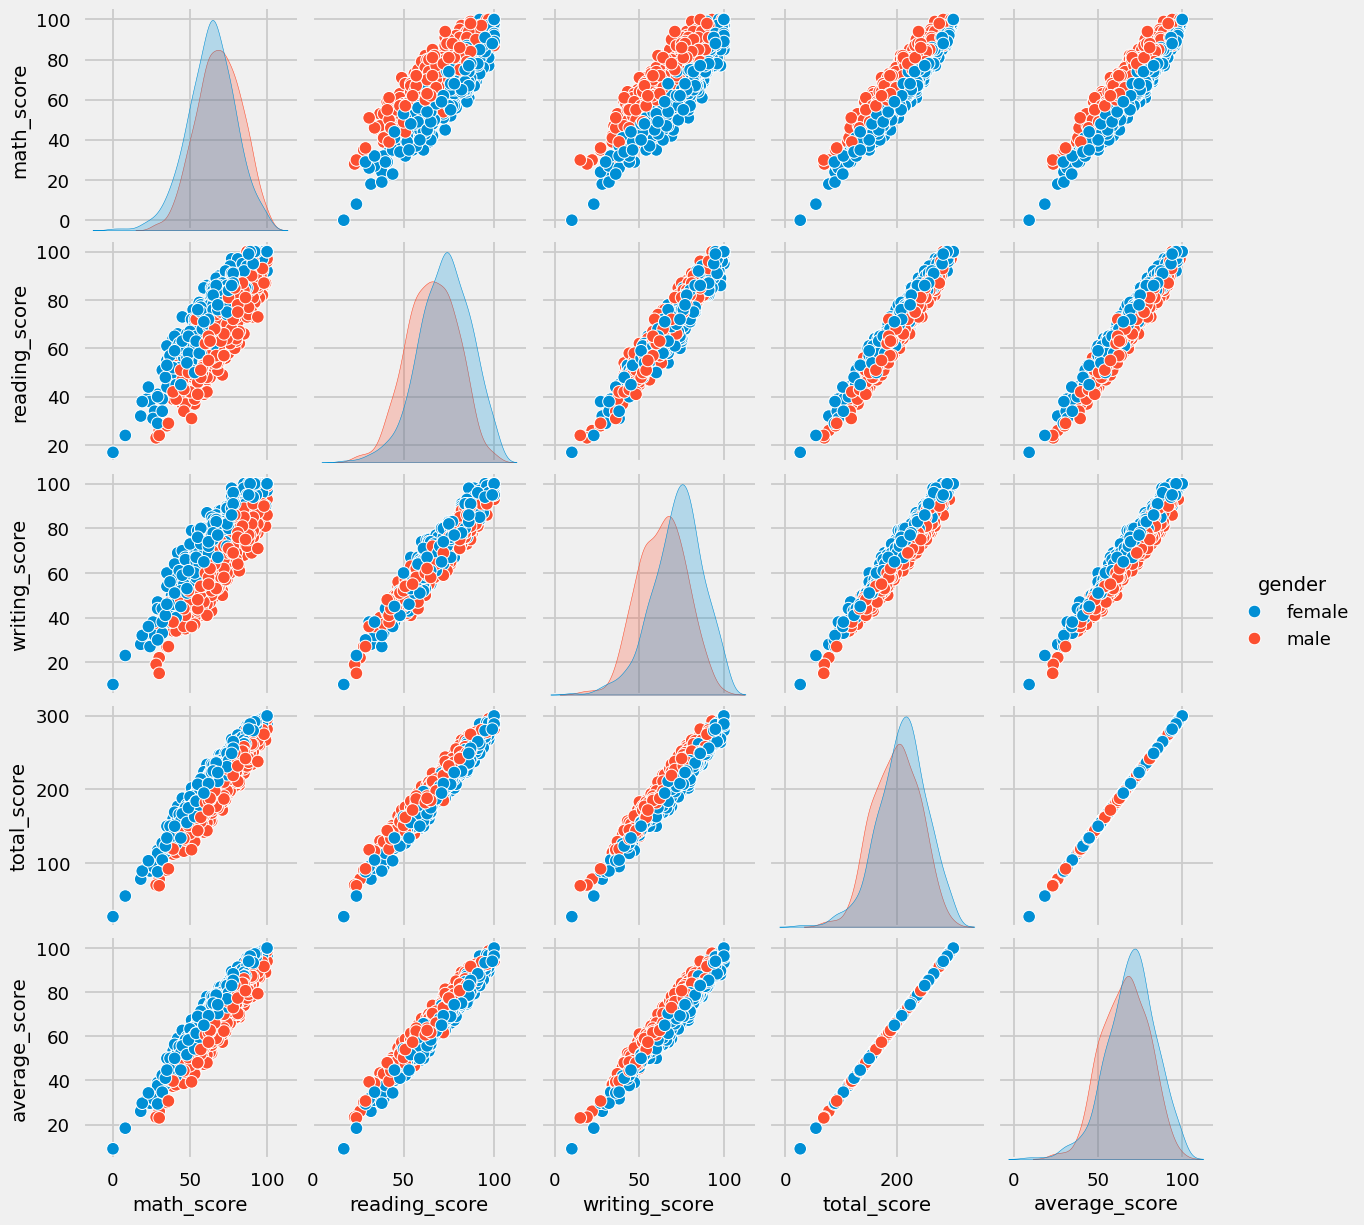

In [34]:
sns.pairplot(df,hue='gender')
plt.show()

## Insights
* From the above plot it is clear that all the scores increase linearly with each other.

## Conclusion
* Students performance is related with lunch,race and parental level education.
* Females lead in pass percentage and also are top scorers.
* Students performance are not much related with test preparation course.
* Finising preparation course is beneficial.